# Below is the Model for Single Feature House Price Prediction

In [49]:
import os
import kagglehub
import os
# %load_ext cudf.pandas
import pandas as pd
import numpy as np
from kagglehub import KaggleDatasetAdapter

dataset_dir = '/kaggle/input/housing-price-prediction-dataset'
print(f"Files available in the dataset directory '{dataset_dir}':\n{os.listdir(dataset_dir)}")

Files available in the dataset directory '/kaggle/input/housing-price-prediction-dataset':
['data_dictionary.csv', 'housing_price_dataset.csv', 'housing_price_dataset.json', 'validation.csv', 'train.csv', 'test.csv', 'dataset_metadata.json']


In [50]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import os
import pandas as pd
import numpy as np
from kagglehub import KaggleDatasetAdapter

# Set the name of the file within the Kaggle dataset you'd like to load
file_name_in_dataset = "housing_price_dataset.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ameyac11/housing-price-prediction-dataset",
  file_name_in_dataset,
)

df.head(5)

Using Colab cache for faster access to the 'housing-price-prediction-dataset' dataset.


,property_id,city,locality,locality_tier,property_type,bhk,bathrooms,balconies,built_up_area,carpet_area,...,power_backup,lift_available,maintenance_fee_monthly,distance_to_city_center_km,distance_to_metro_km,nearby_schools,nearby_hospitals,transaction_type,price_in_lakhs,price_category
0,PROP-000001,Bangalore,HSR Layout,Standard,Apartment,4,4,1,1570,1361,...,1,0,3094,11.6,3.5,3,1,New,102.34,Low
1,PROP-000002,Mumbai,Powai,Standard,Row House,2,1,1,908,778,...,1,1,3893,24.2,1.3,3,2,Resale,71.48,Low
2,PROP-000003,Bangalore,Indiranagar,Premium,Independent House,3,3,2,1784,1568,...,1,1,7038,5.0,0.1,2,1,Resale,245.57,High
3,PROP-000004,Mumbai,Powai,Standard,Independent House,4,4,2,2318,2011,...,0,1,3569,11.9,7.9,2,0,New,122.95,Low
4,PROP-000005,Bangalore,Electronic City,Standard,Apartment,3,4,2,988,840,...,1,1,2628,11.4,7.2,1,0,Resale,64.71,Low


In [51]:
single_Feature_Dataset_All = df[["carpet_area", "price_in_lakhs"]]
single_Feature_Dataset_Model_Building = single_Feature_Dataset_All.loc[: len(single_Feature_Dataset_All)/4]
single_Feature_Dataset_Testing = single_Feature_Dataset_All.loc[len(single_Feature_Dataset_All)/4:]

X = single_Feature_Dataset_Model_Building[["carpet_area"]]
y = single_Feature_Dataset_Model_Building["price_in_lakhs"]

# Reshape X to be a 2D array for scikit-learn models
X = X.values.reshape(-1, 1)


In [52]:
split_index = int(len(X) * 0.7)

X_Train = X[:split_index]
y_Train = y[:split_index]
X_Test = X[split_index:]
y_Test = y[split_index:]

print("X_Train shape:", X_Train.shape)
print("y_Train shape:", y_Train.shape)
print("X_Test shape:", X_Test.shape)
print("y_Test shape:", y_Test.shape)

X_Train shape: (8750, 1)
y_Train shape: (8750,)
X_Test shape: (3751, 1)
y_Test shape: (3751,)


In [53]:
# Linear Line
def compute_model_output(w, b, X):
  m = X.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = w * X[i] + b

  return f_wb

# Find best fit line
def cost_function(w, b, X, y):
  m = X.shape[0]
  cost_sum = 0.0

  for i in range(m):
    f_wb = w * X[i] + b
    cost = (f_wb - y[i]) ** 2
    cost_sum = cost_sum + cost

  total_cost = (1 / (2 *m)) * cost_sum
  return total_cost

# Find best w and b point using gradient descent
def compute_gradient_descent(w, b, X, y):

  m = X.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb = w * X[i] + b
    dj_dw_i = (f_wb - y[i])* X[i]
    dj_db_i = (f_wb -y[i])
    dj_dw += dj_dw_i
    dj_db += dj_db_i
  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw, dj_db


def gradient_descent(w_in, b_in, X, y, alpha, num_iters, cost_function, compute_gradient_descent):

  b = b_in
  w = w_in
  J_history = []
  p_history = []
  for i in range(num_iters):
    dj_dw, dj_db = compute_gradient_descent(w, b, X, y)

    b = b - alpha * dj_db
    w = w - alpha * dj_dw

    # Save cost J at each iteration
    if i<100000:      # prevent resource exhaustion
        J_history.append( cost_function(w, b, X, y))
        p_history.append([w,b])
    # Print cost every at intervals 10 times or as many iterations if < 10
    if i% math.ceil(num_iters/10) == 0:
        print(f"Iteration {i:4}: Cost {J_history[-1].item():0.2e} ",
              f"dj_dw: {dj_dw.item(): 0.3e}, dj_db: {dj_db.item(): 0.3e}  ",
              f"w: {w.item(): 0.3e}, b:{b.item(): 0.5e}")

  return w, b, J_history, p_history

In [54]:
import math
w_in = 0
b_in= 0
num_iters = 10000
alpha = 1.0e-7 # Reduced learning rate
w_final, b_final, J_history, p_history = gradient_descent(w_in, b_in, X_Train, y_Train, alpha, num_iters, cost_function, compute_gradient_descent)
w_final, b_final

Iteration    0: Cost 1.33e+04  dj_dw: -2.622e+05, dj_db: -1.672e+02   w:  2.622e-02, b: 1.67248e-05
Iteration 1000: Cost 2.78e+03  dj_dw: -5.858e-04, dj_db:  9.133e-01   w:  1.276e-01, b:-9.57282e-06
Iteration 2000: Cost 2.78e+03  dj_dw: -5.858e-04, dj_db:  9.133e-01   w:  1.276e-01, b:-1.00900e-04
Iteration 3000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-1.92226e-04
Iteration 4000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-2.83550e-04
Iteration 5000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-3.74873e-04
Iteration 6000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-4.66194e-04
Iteration 7000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-5.57514e-04
Iteration 8000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-6.48833e-04
Iteration 9000: Cost 2.78e+03  dj_dw: -5.857e-04, dj_db:  9.132e-01   w:  1.276e-01, b:-7.40150e-04


(array([0.12761041]), array([-0.00083137]))

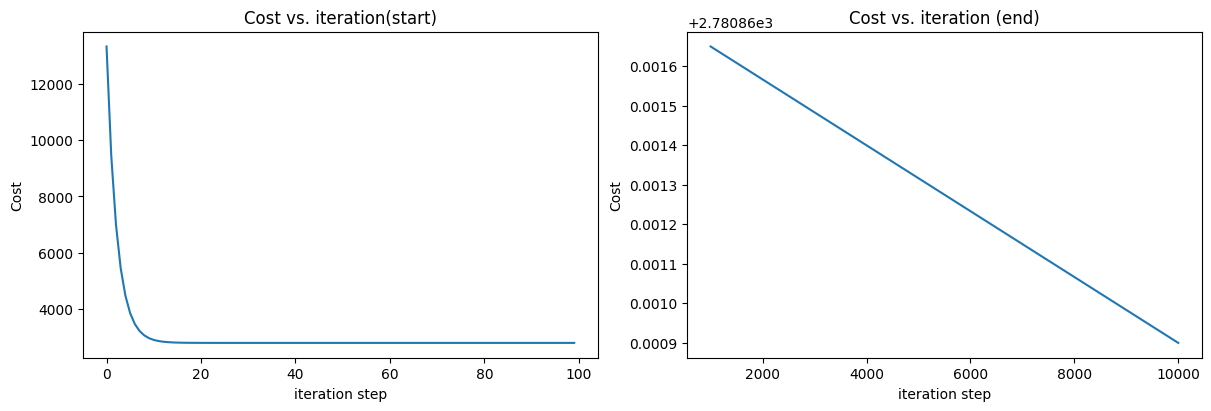

In [55]:
import matplotlib.pyplot as plt
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_history[:100])
ax2.plot(1000 + np.arange(len(J_history[1000:])), J_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

In [62]:
y_predict = compute_model_output(w_final, b_final, X_Test)
y_predict

/tmp/ipykernel_4786/3686890655.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_wb[i] = w * X[i] + b


array([296.43815708, 199.83707475, 106.93669438, ...,  34.70920085,
        39.81361735,  31.90177177])

In [67]:
X1_Train = single_Feature_Dataset_Testing["carpet_area"]
X1_Train = X1_Train.values.reshape(-1, 1)
y_predict = compute_model_output(w_final, b_final, X_Test)
prdicting_Data = single_Feature_Dataset_Model_Building[split_index:]
prdicting_Data["Predcited Price"] = y_predict
prdicting_Data

/tmp/ipykernel_4786/3686890655.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_wb[i] = w * X[i] + b
/tmp/ipykernel_4786/2619020070.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prdicting_Data["Predcited Price"] = y_predict


,carpet_area,price_in_lakhs,Predcited Price
8750,2323,285.06,296.438157
8751,1566,317.33,199.837075
8752,838,112.19,106.936694
8753,1442,147.38,184.013384
8754,1194,89.84,152.366001
...,...,...,...
12496,1916,132.94,244.500719
12497,2305,372.73,294.141170
12498,272,13.05,34.709201
12499,312,45.25,39.813617


In [68]:
from sklearn.metrics import r2_score

# Get the actual values from the testing set
y_true = prdicting_Data["price_in_lakhs"]

# Get the predicted values
y_predicted = prdicting_Data["Predcited Price"]

# Calculate the R-squared score
r_squared = r2_score(y_true, y_predicted)

print(f"R-squared score: {r_squared:.4f}")

R-squared score: 0.5056
